In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_e6eccf76cf44ba265da00e56c030f6cc"
!kaggle datasets download -d juanschafle/cyber-attack-detection-using-network-traffic
!unzip -q cyber-attack-detection-using-network-traffic.zip
print("Klasördeki dosyalar:", os.listdir())

Dataset URL: https://www.kaggle.com/datasets/juanschafle/cyber-attack-detection-using-network-traffic
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 785k/785k [00:00<00:00, 79.5MB/s]

Klasördeki dosyalar: ['.config', 'cyber-attack-detection-using-network-traffic.zip', 'cyber_attack_dataset_100000.csv', 'sample_data']


In [2]:
import pandas as pd
import os

csv_files = [f for f in os.listdir() if f.endswith('.csv')]

if len(csv_files) > 0:
    file_name = csv_files[0]
    print(f"✅ Okunan dosya: {file_name}")

    df = pd.read_csv(file_name)

    print(f"\n📏 Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")

    print("\n🔍 Veri Tipleri ve Eksik Veri Durumu:")
    df.info()

    display(df.head())
else:
    print("❌ CSV dosyası bulunamadı!")

✅ Okunan dosya: cyber_attack_dataset_100000.csv

📏 Veri seti boyutu: 100000 satır, 7 sütun

🔍 Veri Tipleri ve Eksik Veri Durumu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   duration       100000 non-null  int64 
 1   src_bytes      100000 non-null  int64 
 2   dst_bytes      100000 non-null  int64 
 3   packet_count   100000 non-null  int64 
 4   protocol       100000 non-null  object
 5   failed_logins  100000 non-null  int64 
 6   attack_type    100000 non-null  object
dtypes: int64(5), object(2)
memory usage: 5.3+ MB


,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce


--- Saldırı Türleri Dağılımı ---
attack_type
DDoS          25077
BruteForce    25039
PortScan      25008
Normal        24876
Name: count, dtype: int64


/tmp/ipykernel_3827/2815052070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='attack_type', order=df['attack_type'].value_counts().index, palette='magma')


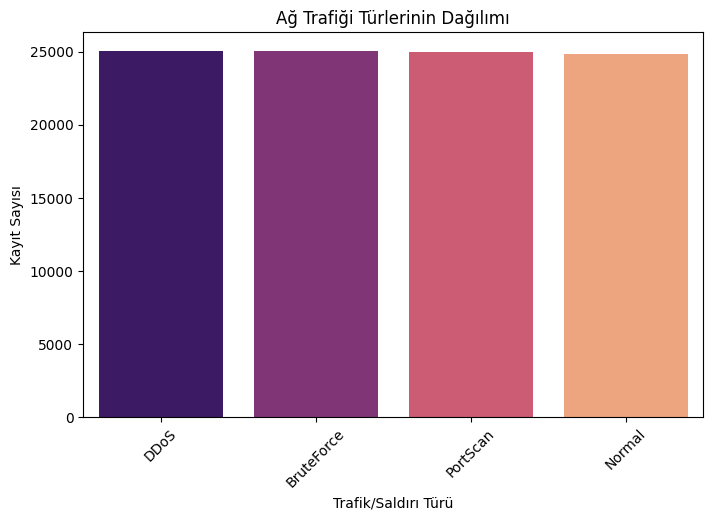


--- Protokol Dağılımı ---
protocol
TCP    50186
UDP    49814
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Saldırı Türleri Dağılımı ---")
print(df['attack_type'].value_counts())
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='attack_type', order=df['attack_type'].value_counts().index, palette='magma')
plt.title('Ağ Trafiği Türlerinin Dağılımı')
plt.ylabel('Kayıt Sayısı')
plt.xlabel('Trafik/Saldırı Türü')
plt.xticks(rotation=45)
plt.show()

print("\n--- Protokol Dağılımı ---")
print(df['protocol'].value_counts())

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

le = LabelEncoder()
df['target'] = le.fit_transform(df['attack_type'])
print("Hedef Sınıf Eşleşmeleri:", dict(zip(le.classes_, le.transform(le.classes_))))

df_processed = pd.get_dummies(df, columns=['protocol'], drop_first=True)

X = df_processed.drop(['attack_type', 'target'], axis=1)
y = df_processed['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Veri ön işleme başarıyla tamamlandı!")
print(f"Eğitim seti boyutu: {X_train_scaled.shape}")
print(f"Test seti boyutu: {X_test_scaled.shape}")

Hedef Sınıf Eşleşmeleri: {'BruteForce': np.int64(0), 'DDoS': np.int64(1), 'Normal': np.int64(2), 'PortScan': np.int64(3)}

✅ Veri ön işleme başarıyla tamamlandı!
Eğitim seti boyutu: (80000, 6)
Test seti boyutu: (20000, 6)


**Eğitim Aşaması **

🚀 Model eğitiliyor, lütfen bekleyin...
✅ Model eğitimi tamamlandı!

📊 Sınıflandırma Raporu:
              precision    recall  f1-score   support

  BruteForce       1.00      1.00      1.00      5008
        DDoS       1.00      1.00      1.00      5015
      Normal       1.00      1.00      1.00      4975
    PortScan       1.00      1.00      1.00      5002

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



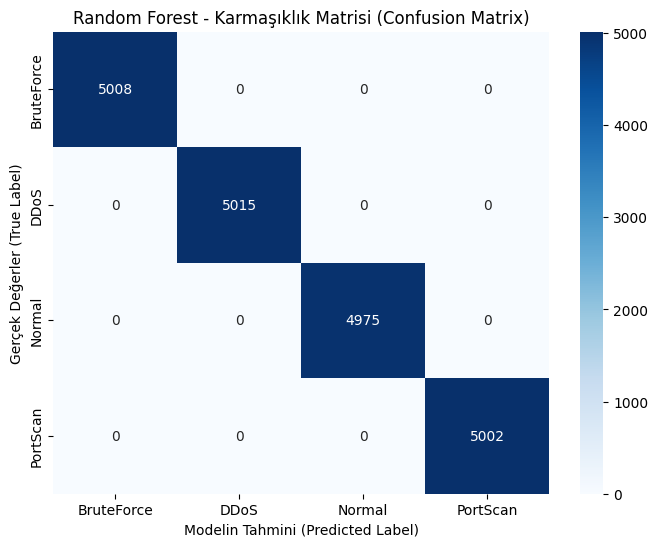

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Model eğitiliyor, lütfen bekleyin...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("✅ Model eğitimi tamamlandı!\n")

y_pred = rf_model.predict(X_test_scaled)

print("📊 Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değerler (True Label)')
plt.xlabel('Modelin Tahmini (Predicted Label)')
plt.show()

/tmp/ipykernel_3827/3555535394.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Derecesi', y='Özellik (Feature)', data=feature_importance_df, palette='viridis')


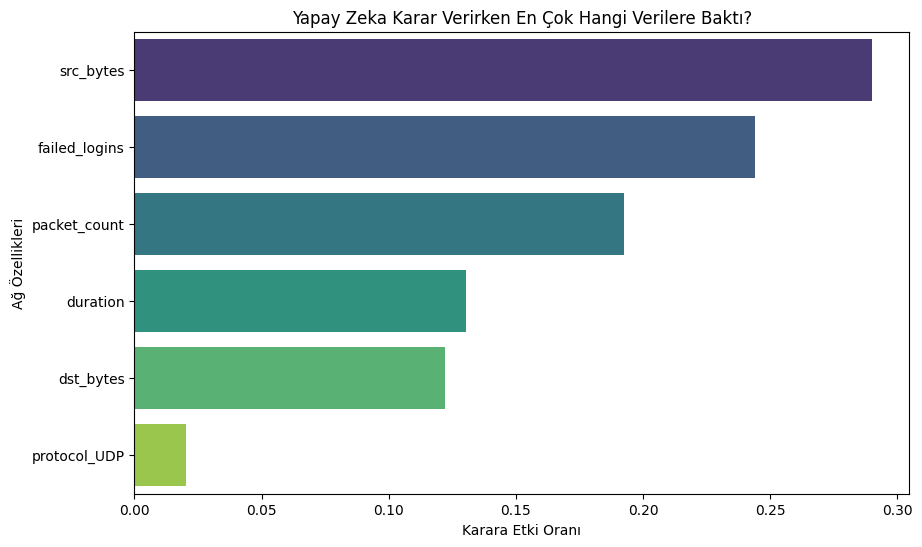

🔍 En Önemli 3 Özellik:


,Özellik (Feature),Önem Derecesi
1,src_bytes,0.290175
4,failed_logins,0.244138
3,packet_count,0.192449


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


importances = rf_model.feature_importances_

features = X.columns

feature_importance_df = pd.DataFrame({
    'Özellik (Feature)': features,
    'Önem Derecesi': importances
}).sort_values(by='Önem Derecesi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Özellik (Feature)', data=feature_importance_df, palette='viridis')
plt.title('Yapay Zeka Karar Verirken En Çok Hangi Verilere Baktı?')
plt.xlabel('Karara Etki Oranı')
plt.ylabel('Ağ Özellikleri')
plt.show()

print("🔍 En Önemli 3 Özellik:")
display(feature_importance_df.head(3))

In [8]:
import joblib
import numpy as np

joblib.dump(rf_model, 'siber_guvenlik_rf_modeli.pkl')
joblib.dump(scaler, 'veri_olceklendirici.pkl')
print("💾 Model ve Ölçeklendirici başarıyla kaydedildi!\n")

def ag_trafigini_analiz_et(duration, src_bytes, dst_bytes, packet_count, protocol_UDP, failed_logins):
    print(f"📡 Yeni Ağ Trafiği Algılandı! Analiz ediliyor...")


    yeni_veri = np.array([[duration, src_bytes, dst_bytes, packet_count, failed_logins, protocol_UDP]])
    yuklenen_scaler = joblib.load('veri_olceklendirici.pkl')
    yeni_veri_scaled = yuklenen_scaler.transform(yeni_veri)

    yuklenen_model = joblib.load('siber_guvenlik_rf_modeli.pkl')
    tahmin_kodu = yuklenen_model.predict(yeni_veri_scaled)[0]


    ters_eslesme = {0: 'BruteForce', 1: 'DDoS', 2: 'Normal', 3: 'PortScan'}
    sonuc = ters_eslesme[tahmin_kodu]

    if sonuc == 'Normal':
        print(f"✅ GÜVENLİ: Bu trafik zararsız görünüyor. (Tespit: {sonuc})\n")
    else:
        print(f"🚨 ALARM! SİBER SALDIRI TESPİT EDİLDİ! (Tespit: {sonuc})\n")


print("--- Senaryo 1 ---")
ag_trafigini_analiz_et(duration=5, src_bytes=150, dst_bytes=400, packet_count=10, protocol_UDP=1, failed_logins=0)

print("--- Senaryo 2 ---")
ag_trafigini_analiz_et(duration=1, src_bytes=95000, dst_bytes=200, packet_count=15000, protocol_UDP=0, failed_logins=0)

print("--- Senaryo 3 ---")
ag_trafigini_analiz_et(duration=45, src_bytes=300, dst_bytes=100, packet_count=20, protocol_UDP=0, failed_logins=15)

💾 Model ve Ölçeklendirici başarıyla kaydedildi!

--- Senaryo 1 ---
📡 Yeni Ağ Trafiği Algılandı! Analiz ediliyor...
✅ GÜVENLİ: Bu trafik zararsız görünüyor. (Tespit: Normal)

--- Senaryo 2 ---
📡 Yeni Ağ Trafiği Algılandı! Analiz ediliyor...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


🚨 ALARM! SİBER SALDIRI TESPİT EDİLDİ! (Tespit: DDoS)

--- Senaryo 3 ---
📡 Yeni Ağ Trafiği Algılandı! Analiz ediliyor...
🚨 ALARM! SİBER SALDIRI TESPİT EDİLDİ! (Tespit: BruteForce)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
